In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier

from mpl_toolkits.mplot3d import Axes3D

In [12]:
df = pd.read_csv('bank.csv', sep = ';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB
None


In [14]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [16]:
print("\nSummary statistics for numerical columns:")
print(df.describe())


Summary statistics for numerical columns:
               age       balance          day     duration     campaign  \
count  4521.000000   4521.000000  4521.000000  4521.000000  4521.000000   
mean     41.170095   1422.657819    15.915284   263.961292     2.793630   
std      10.576211   3009.638142     8.247667   259.856633     3.109807   
min      19.000000  -3313.000000     1.000000     4.000000     1.000000   
25%      33.000000     69.000000     9.000000   104.000000     1.000000   
50%      39.000000    444.000000    16.000000   185.000000     2.000000   
75%      49.000000   1480.000000    21.000000   329.000000     3.000000   
max      87.000000  71188.000000    31.000000  3025.000000    50.000000   

             pdays     previous  
count  4521.000000  4521.000000  
mean     39.766645     0.542579  
std     100.121124     1.693562  
min      -1.000000     0.000000  
25%      -1.000000     0.000000  
50%      -1.000000     0.000000  
75%      -1.000000     0.000000  
max     8

In [17]:
print("\nSummary statistics for categorical columns:")
print(df.describe(include="object"))


Summary statistics for categorical columns:
               job  marital  education default housing  loan   contact month  \
count         4521     4521       4521    4521    4521  4521      4521  4521   
unique          12        3          4       2       2     2         3    12   
top     management  married  secondary      no     yes    no  cellular   may   
freq           969     2797       2306    4445    2559  3830      2896  1398   

       poutcome     y  
count      4521  4521  
unique        4     2  
top     unknown    no  
freq       3705  4000  


In [18]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

# Target column
target_column = "y"

# Remove target from categorical columns if present
if target_column in categorical_columns:
    categorical_feature_columns = [col for col in categorical_columns if col != target_column]
else:
    categorical_feature_columns = categorical_columns

print("\nCategorical feature columns:")
print(categorical_feature_columns)

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Categorical feature columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [19]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nCount of 'unknown' values in each categorical column:")
for col in categorical_feature_columns:
    unknown_count = (df[col] == "unknown").sum()
    print(f"{col}: {unknown_count}")


Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Count of 'unknown' values in each categorical column:
job: 38
marital: 0
education: 187
default: 0
housing: 0
loan: 0
contact: 1324
month: 0
poutcome: 3705



Target value counts:
y
no     4000
yes     521
Name: count, dtype: int64

Target value percentage:
y
no     88.476001
yes    11.523999
Name: proportion, dtype: float64


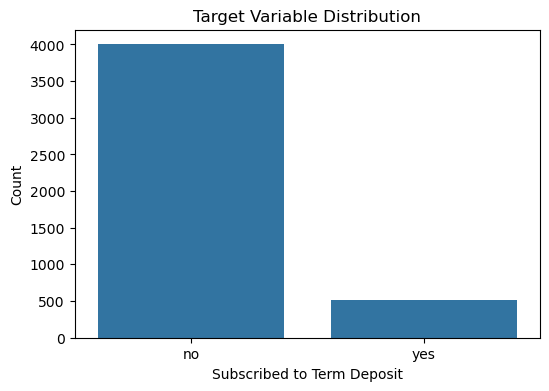

In [20]:
# ============================================================
# Target Variable Distribution
# ============================================================

print("\nTarget value counts:")
print(df[target_column].value_counts())

print("\nTarget value percentage:")
print(df[target_column].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_column)
plt.title("Target Variable Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Count")
plt.savefig("target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

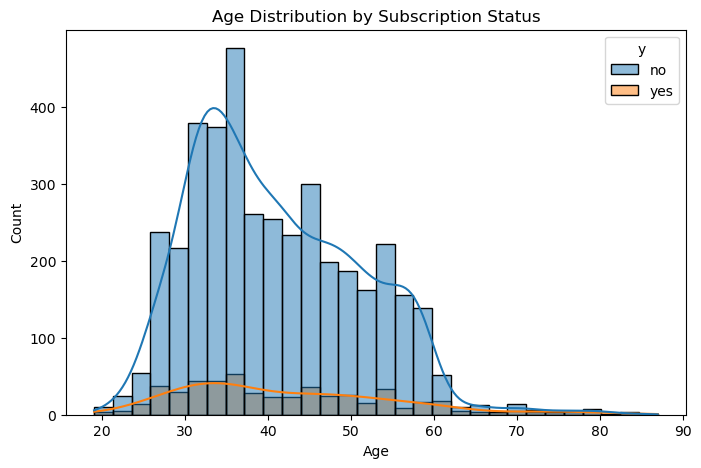

In [21]:
# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", hue=target_column, bins=30, kde=True)
plt.title("Age Distribution by Subscription Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("age_distribution_by_subscription.png", dpi=300, bbox_inches="tight")
plt.show()

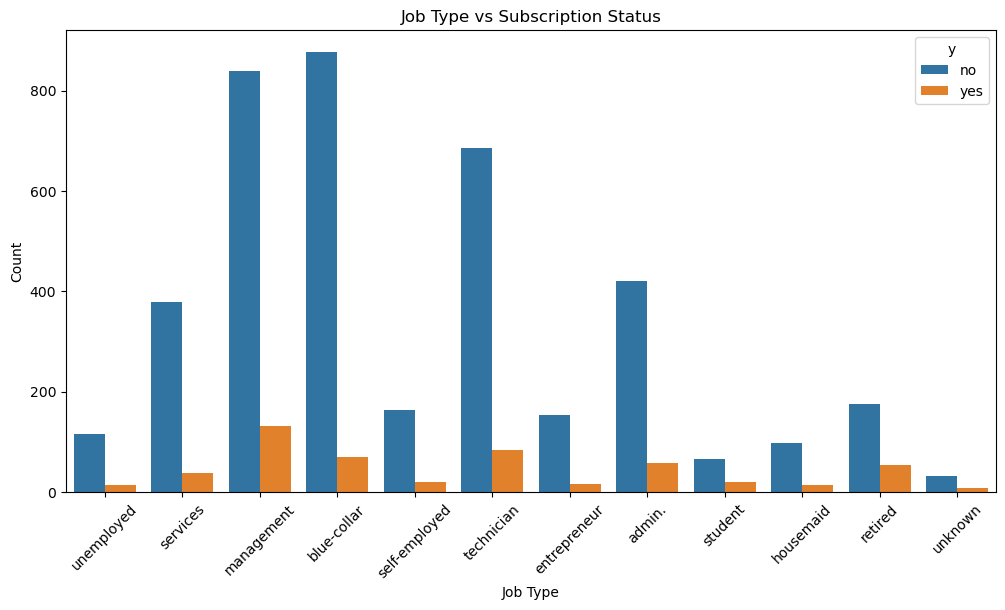

In [22]:
# ============================================================
# Job Type vs Subscription
# ============================================================

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="job", hue=target_column)
plt.title("Job Type vs Subscription Status")
plt.xlabel("Job Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("job_vs_subscription.png", dpi=300, bbox_inches="tight")
plt.show()

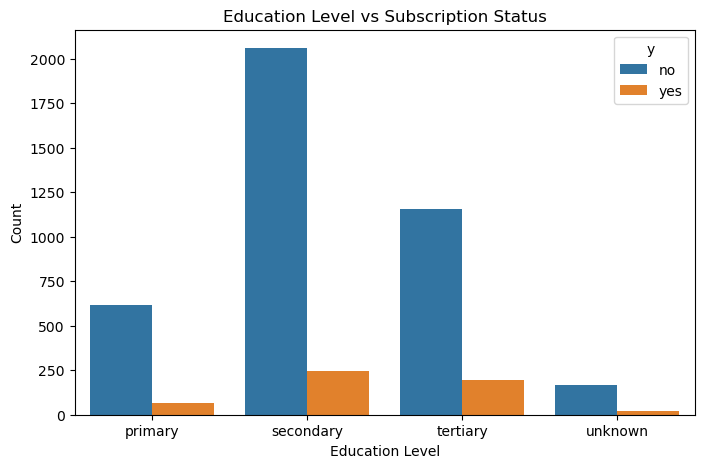

In [23]:
# ============================================================
# Education vs Subscription
# ============================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="education", hue=target_column)
plt.title("Education Level vs Subscription Status")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.savefig("education_vs_subscription.png", dpi=300, bbox_inches="tight")
plt.show()

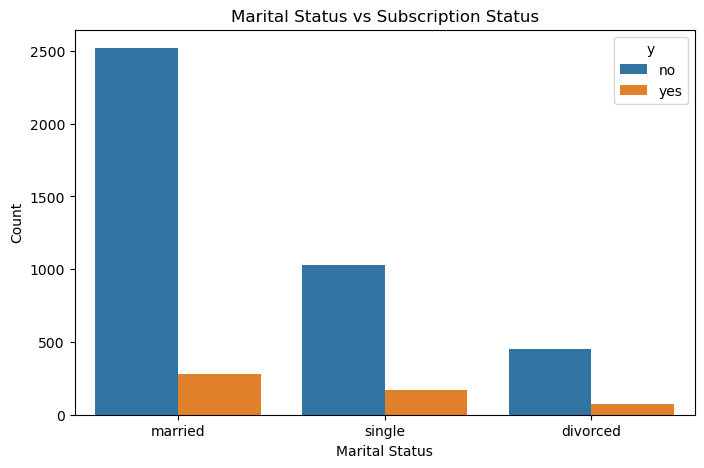

In [24]:
# ============================================================
# Marital Status vs Subscription
# ============================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="marital", hue=target_column)
plt.title("Marital Status vs Subscription Status")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.savefig("marital_status_vs_subscription.png", dpi=300, bbox_inches="tight")
plt.show()

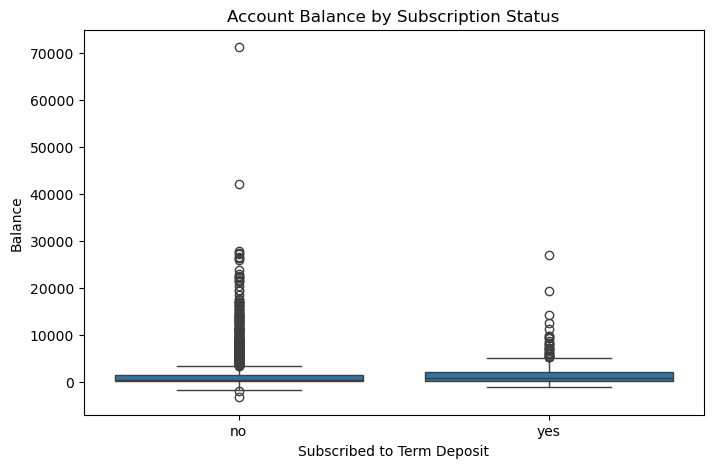

In [25]:
# ============================================================
# Balance Distribution
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=target_column, y="balance")
plt.title("Account Balance by Subscription Status")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Balance")
plt.savefig("balance_boxplot_by_subscription.png", dpi=300, bbox_inches="tight")
plt.show()

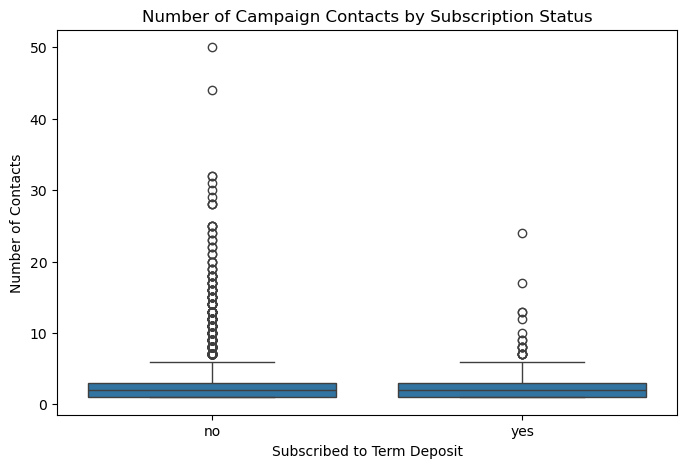

In [26]:
# ============================================================
# Campaign Contacts vs Subscription
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=target_column, y="campaign")
plt.title("Number of Campaign Contacts by Subscription Status")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Contacts")
plt.savefig("campaign_contacts_by_subscription.png", dpi=300, bbox_inches="tight")
plt.show()

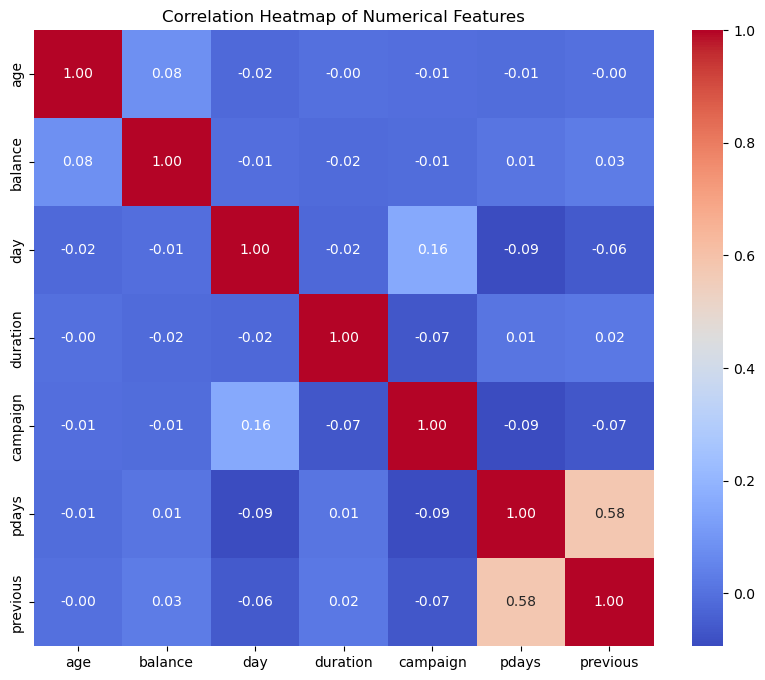

In [27]:
# ============================================================
# Correlation Heatmap for Numerical Variables
# ============================================================

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
# ============================================================
# Data Cleaning
# ============================================================

df_clean = df.copy()

# Replace "unknown" with NaN
df_clean = df_clean.replace("unknown", np.nan)

print("\nMissing values after replacing 'unknown' with NaN:")
print(df_clean.isnull().sum())

# Separate features and target
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

# Encode target variable: yes = 1, no = 0
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nTarget encoding:")
for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(original, "=", encoded)


Missing values after replacing 'unknown' with NaN:
age             0
job            38
marital         0
education     187
default         0
balance         0
housing         0
loan            0
contact      1324
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     3705
y               0
dtype: int64

Target encoding:
no = 0
yes = 1


In [29]:
# ============================================================
# Define Numerical, Ordinal, and Nominal Features
# ============================================================

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Education is ordinal because it has a natural order
ordinal_features = ["education"]

# Other categorical columns are nominal
nominal_features = X.select_dtypes(include=["object"]).columns.tolist()
nominal_features = [col for col in nominal_features if col not in ordinal_features]

print("Numerical features:")
print(numerical_features)

print("\nOrdinal features:")
print(ordinal_features)

print("\nNominal features:")
print(nominal_features)

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Ordinal features:
['education']

Nominal features:
['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [30]:
# ============================================================
# Preprocessing Pipeline
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal_encoder", OrdinalEncoder(
        categories=[["primary", "secondary", "tertiary"]]
    )),
    ("scaler", StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot_encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("nom", nominal_transformer, nominal_features)
    ]
)

In [31]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (3616, 16)
Testing data shape: (905, 16)


In [32]:
# ============================================================
# SVM Classification Model
# ============================================================

svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_pred_proba_svm = svm_model.predict_proba(X_test)[:, 1]

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_pred_proba_svm)

print("SVM Accuracy:", svm_accuracy)
print("SVM Precision:", svm_precision)
print("SVM Recall:", svm_recall)
print("SVM F1-score:", svm_f1)
print("SVM ROC-AUC:", svm_auc)


SVM Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       801
           1       0.63      0.21      0.32       104

    accuracy                           0.90       905
   macro avg       0.77      0.60      0.63       905
weighted avg       0.87      0.90      0.87       905

SVM Accuracy: 0.8950276243093923
SVM Precision: 0.6285714285714286
SVM Recall: 0.21153846153846154
SVM F1-score: 0.31654676258992803
SVM ROC-AUC: 0.8628097090175741


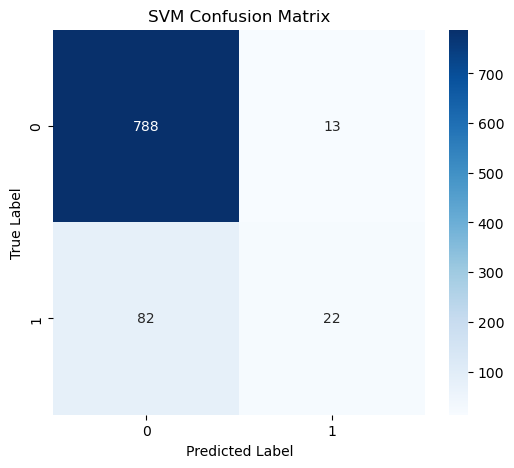

In [33]:
# ============================================================
# SVM Confusion Matrix
# ============================================================

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("svm_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

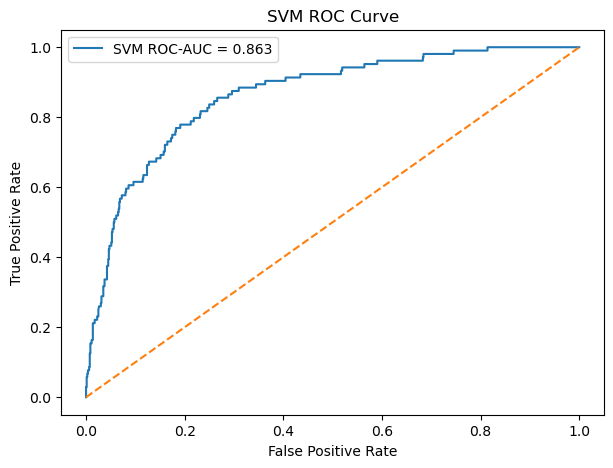

In [34]:
# ============================================================
# SVM ROC Curve
# ============================================================

fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_pred_proba_svm)

plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, label=f"SVM ROC-AUC = {svm_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("SVM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("svm_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

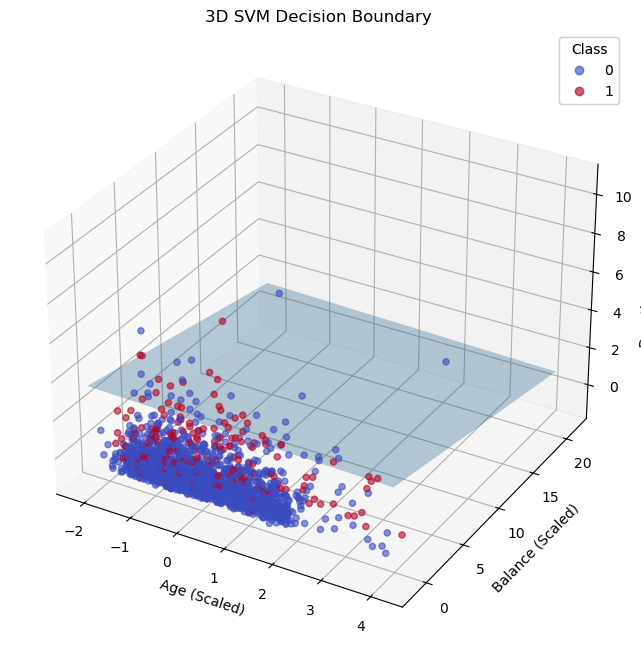

In [35]:
# ============================================================
# 3D SVM Visualization with Decision Boundary
# ============================================================

features_3d = ["age", "balance", "duration"]

df_3d = df_clean[features_3d + [target_column]].copy()
df_3d = df_3d.dropna()

X_3d = df_3d[features_3d]
y_3d = label_encoder.fit_transform(df_3d[target_column])

# To make visualization easier and faster, sample data
sample_size = 2000

if len(df_3d) > sample_size:
    df_3d_sample = df_3d.sample(n=sample_size, random_state=42)
else:
    df_3d_sample = df_3d.copy()

X_3d_sample = df_3d_sample[features_3d]
y_3d_sample = label_encoder.fit_transform(df_3d_sample[target_column])

# Scale the 3 selected features
scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d_sample)

# Linear SVM is used because its boundary is easier to visualize as a plane in 3D
svm_3d = LinearSVC(C=1.0, random_state=42, max_iter=10000)
svm_3d.fit(X_3d_scaled, y_3d_sample)

# Extract coefficients for decision plane
coef = svm_3d.coef_[0]
intercept = svm_3d.intercept_[0]

# Create grid for decision plane
x_range = np.linspace(X_3d_scaled[:, 0].min(), X_3d_scaled[:, 0].max(), 30)
y_range = np.linspace(X_3d_scaled[:, 1].min(), X_3d_scaled[:, 1].max(), 30)

xx, yy = np.meshgrid(x_range, y_range)

# Decision boundary equation:
# coef[0]*x + coef[1]*y + coef[2]*z + intercept = 0
zz = -(coef[0] * xx + coef[1] * yy + intercept) / coef[2]

# 3D plot
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_3d_scaled[:, 0],
    X_3d_scaled[:, 1],
    X_3d_scaled[:, 2],
    c=y_3d_sample,
    cmap="coolwarm",
    alpha=0.6
)

ax.plot_surface(xx, yy, zz, alpha=0.3)

ax.set_xlabel("Age (Scaled)")
ax.set_ylabel("Balance (Scaled)")
ax.set_zlabel("Duration (Scaled)")
ax.set_title("3D SVM Decision Boundary")

legend = ax.legend(*scatter.legend_elements(), title="Class")
ax.add_artist(legend)

plt.savefig("svm_3d_decision_boundary.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
# ============================================================
# XGBoost Classification Model
# ============================================================

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost Precision:", xgb_precision)
print("XGBoost Recall:", xgb_recall)
print("XGBoost F1-score:", xgb_f1)
print("XGBoost ROC-AUC:", xgb_auc)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       801
           1       0.55      0.35      0.42       104

    accuracy                           0.89       905
   macro avg       0.73      0.65      0.68       905
weighted avg       0.88      0.89      0.88       905

XGBoost Accuracy: 0.8917127071823204
XGBoost Precision: 0.5454545454545454
XGBoost Recall: 0.34615384615384615
XGBoost F1-score: 0.4235294117647059
XGBoost ROC-AUC: 0.8954131854412753


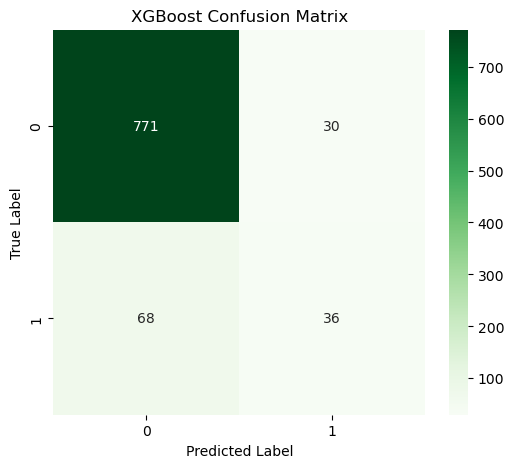

In [37]:
# ============================================================
# XGBoost Confusion Matrix
# ============================================================

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("xgboost_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

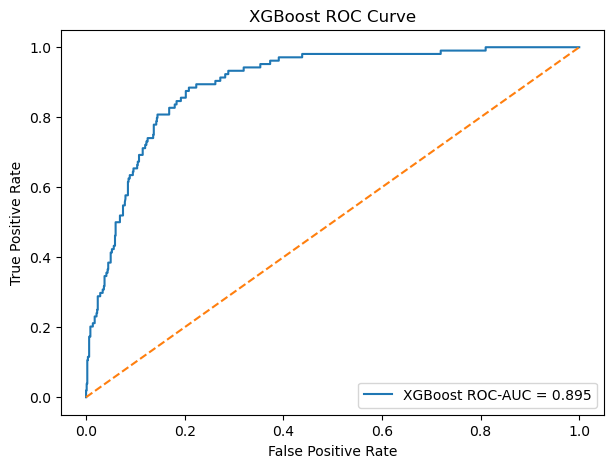

In [38]:
# ============================================================
# XGBoost ROC Curve
# ============================================================

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost ROC-AUC = {xgb_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("XGBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("xgboost_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
# ============================================================
# XGBoost Hyperparameter Tuning
# ============================================================

n_estimators_values = [50, 100, 200, 300]
learning_rate_values = [0.01, 0.05, 0.1, 0.2]

results = []

for n_est in n_estimators_values:
    for lr in learning_rate_values:
        
        model = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", XGBClassifier(
                n_estimators=n_est,
                learning_rate=lr,
                max_depth=4,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42
            ))
        ])
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        error_rate = 1 - accuracy
        
        results.append({
            "n_estimators": n_est,
            "learning_rate": lr,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "roc_auc": auc,
            "error_rate": error_rate
        })

results_df = pd.DataFrame(results)

print("\nXGBoost Tuning Results:")
print(results_df)

best_result = results_df.sort_values(by="error_rate").iloc[0]

print("\nBest Hyperparameter Combination:")
print(best_result)

C:\Users\firoj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



XGBoost Tuning Results:
    n_estimators  learning_rate  accuracy  precision    recall  f1_score  \
0             50           0.01  0.885083   0.000000  0.000000  0.000000   
1             50           0.05  0.895028   0.604651  0.250000  0.353741   
2             50           0.10  0.891713   0.548387  0.326923  0.409639   
3             50           0.20  0.889503   0.530303  0.336538  0.411765   
4            100           0.01  0.890608   0.777778  0.067308  0.123894   
5            100           0.05  0.892818   0.559322  0.317308  0.404908   
6            100           0.10  0.891713   0.545455  0.346154  0.423529   
7            100           0.20  0.892818   0.549296  0.375000  0.445714   
8            200           0.01  0.888398   0.548387  0.163462  0.251852   
9            200           0.05  0.893923   0.564516  0.336538  0.421687   
10           200           0.10  0.891713   0.545455  0.346154  0.423529   
11           200           0.20  0.895028   0.565217  0.375000 

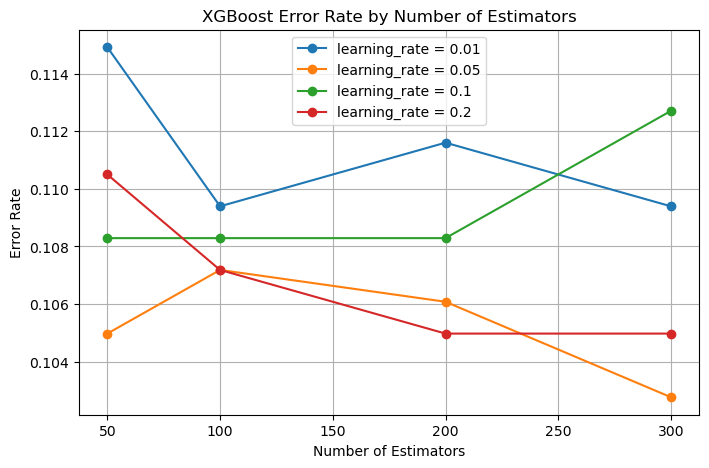

In [40]:
# ============================================================
# Error Rate by Number of Estimators
# ============================================================

plt.figure(figsize=(8, 5))

for lr in learning_rate_values:
    subset = results_df[results_df["learning_rate"] == lr]
    plt.plot(
        subset["n_estimators"],
        subset["error_rate"],
        marker="o",
        label=f"learning_rate = {lr}"
    )

plt.title("XGBoost Error Rate by Number of Estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Error Rate")
plt.legend()
plt.grid(True)
plt.savefig("xgboost_error_rate_by_estimators.png", dpi=300, bbox_inches="tight")
plt.show()

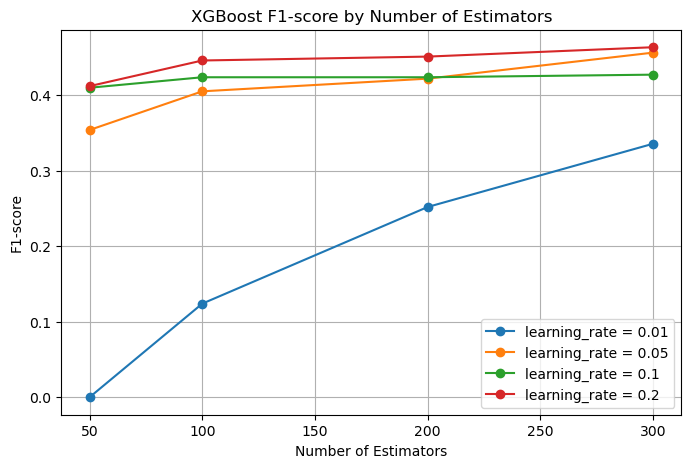

In [41]:
# ============================================================
# F1-score by Number of Estimators
# ============================================================

plt.figure(figsize=(8, 5))

for lr in learning_rate_values:
    subset = results_df[results_df["learning_rate"] == lr]
    plt.plot(
        subset["n_estimators"],
        subset["f1_score"],
        marker="o",
        label=f"learning_rate = {lr}"
    )

plt.title("XGBoost F1-score by Number of Estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.savefig("xgboost_f1_by_estimators.png", dpi=300, bbox_inches="tight")
plt.show()

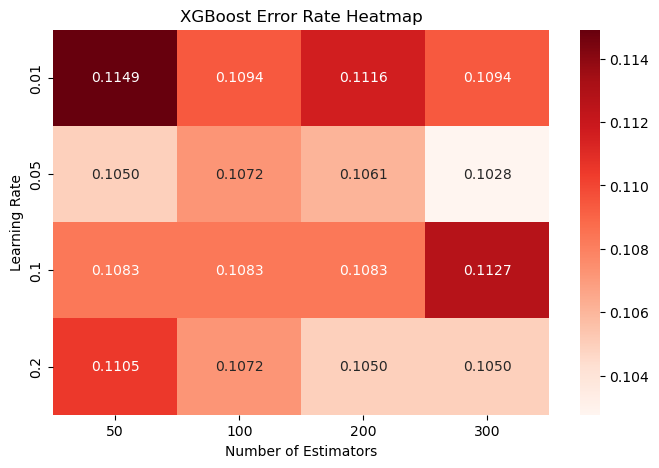

In [42]:
# ============================================================
# Heatmap of XGBoost Error Rate
# ============================================================

pivot_error = results_df.pivot(
    index="learning_rate",
    columns="n_estimators",
    values="error_rate"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_error, annot=True, fmt=".4f", cmap="Reds")
plt.title("XGBoost Error Rate Heatmap")
plt.xlabel("Number of Estimators")
plt.ylabel("Learning Rate")
plt.savefig("xgboost_error_rate_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

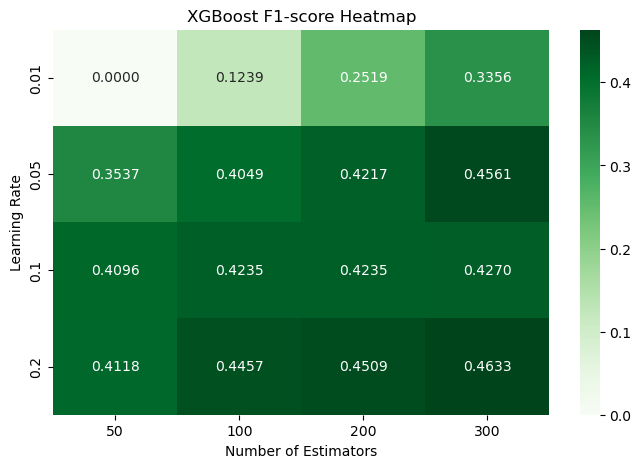

In [43]:
# ============================================================
# Heatmap of XGBoost F1-score
# ============================================================

pivot_f1 = results_df.pivot(
    index="learning_rate",
    columns="n_estimators",
    values="f1_score"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_f1, annot=True, fmt=".4f", cmap="Greens")
plt.title("XGBoost F1-score Heatmap")
plt.xlabel("Number of Estimators")
plt.ylabel("Learning Rate")
plt.savefig("xgboost_f1_score_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
# ============================================================
# Final Optimized XGBoost Model
# ============================================================

best_n_estimators = int(best_result["n_estimators"])
best_learning_rate = float(best_result["learning_rate"])

final_xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=best_n_estimators,
        learning_rate=best_learning_rate,
        max_depth=4,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

final_xgb_model.fit(X_train, y_train)

final_y_pred = final_xgb_model.predict(X_test)
final_y_pred_proba = final_xgb_model.predict_proba(X_test)[:, 1]

print("\nFinal Optimized XGBoost Classification Report:")
print(classification_report(y_test, final_y_pred))

final_accuracy = accuracy_score(y_test, final_y_pred)
final_precision = precision_score(y_test, final_y_pred)
final_recall = recall_score(y_test, final_y_pred)
final_f1 = f1_score(y_test, final_y_pred)
final_auc = roc_auc_score(y_test, final_y_pred_proba)

print("Final XGBoost Accuracy:", final_accuracy)
print("Final XGBoost Precision:", final_precision)
print("Final XGBoost Recall:", final_recall)
print("Final XGBoost F1-score:", final_f1)
print("Final XGBoost ROC-AUC:", final_auc)


Final Optimized XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       801
           1       0.58      0.38      0.46       104

    accuracy                           0.90       905
   macro avg       0.75      0.67      0.70       905
weighted avg       0.88      0.90      0.89       905

Final XGBoost Accuracy: 0.8972375690607735
Final XGBoost Precision: 0.582089552238806
Final XGBoost Recall: 0.375
Final XGBoost F1-score: 0.45614035087719296
Final XGBoost ROC-AUC: 0.900538989724383


In [45]:
# ============================================================
# Model Comparison
# ============================================================

comparison_df = pd.DataFrame({
    "Model": ["SVM", "XGBoost", "Optimized XGBoost"],
    "Accuracy": [svm_accuracy, xgb_accuracy, final_accuracy],
    "Precision": [svm_precision, xgb_precision, final_precision],
    "Recall": [svm_recall, xgb_recall, final_recall],
    "F1-score": [svm_f1, xgb_f1, final_f1],
    "ROC-AUC": [svm_auc, xgb_auc, final_auc]
})

print("\nModel Comparison:")
print(comparison_df)


Model Comparison:
               Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0                SVM  0.895028   0.628571  0.211538  0.316547  0.862810
1            XGBoost  0.891713   0.545455  0.346154  0.423529  0.895413
2  Optimized XGBoost  0.897238   0.582090  0.375000  0.456140  0.900539


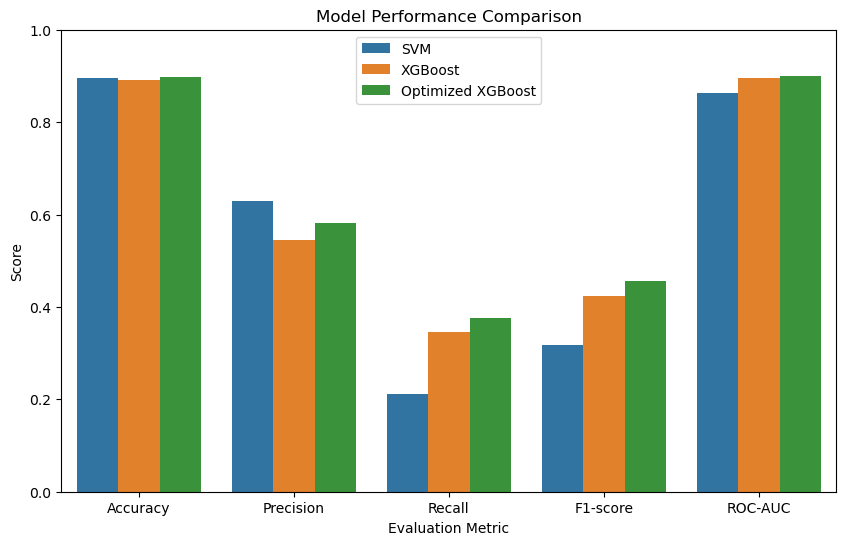

In [46]:
# ============================================================
# Model Comparison Bar Chart
# ============================================================

comparison_melted = comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


Top 20 Important Features:
             Feature  Importance
44  poutcome_success    0.178212
3           duration    0.079553
42  poutcome_failure    0.056636
40         month_oct    0.052232
30         month_apr    0.041761
37         month_mar    0.038568
9    job_blue-collar    0.033995
38         month_may    0.033103
33         month_feb    0.031695
24        housing_no    0.030019
5              pdays    0.023019
26           loan_no    0.022224
10  job_entrepreneur    0.022004
31         month_aug    0.021287
16       job_student    0.019775
13       job_retired    0.019278
35         month_jul    0.019131
2                day    0.018802
6           previous    0.018243
0                age    0.018203


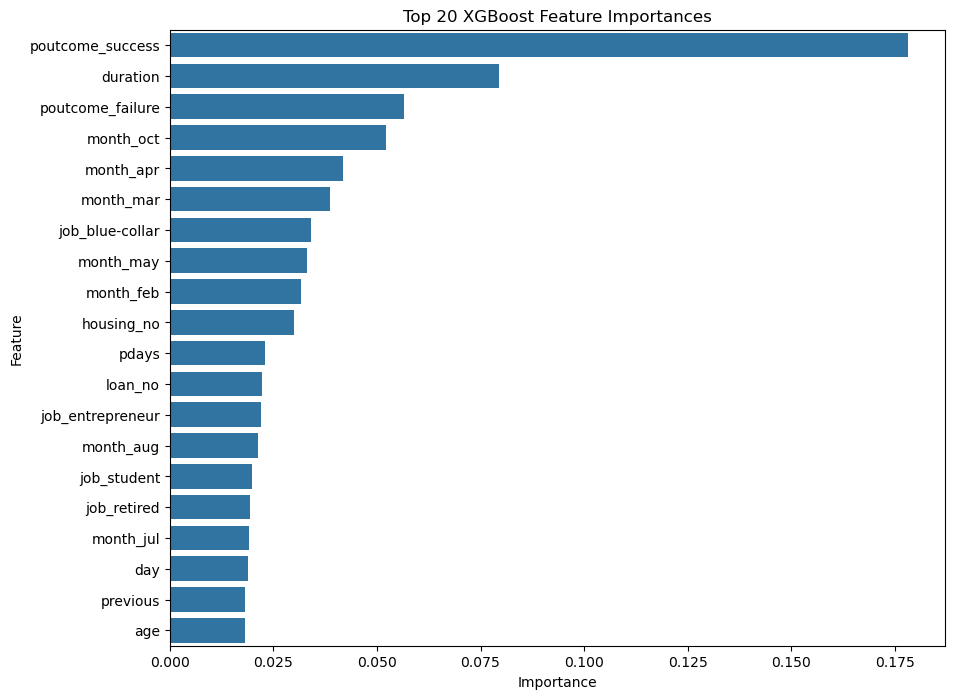

In [47]:
# ============================================================
# XGBoost Feature Importance
# ============================================================

# Get trained preprocessor and classifier
trained_preprocessor = final_xgb_model.named_steps["preprocessor"]
trained_classifier = final_xgb_model.named_steps["classifier"]

# Get feature names after preprocessing
onehot_feature_names = trained_preprocessor.named_transformers_["nom"] \
    .named_steps["onehot_encoder"] \
    .get_feature_names_out(nominal_features)

all_feature_names = (
    numerical_features
    + ordinal_features
    + list(onehot_feature_names)
)

feature_importance = trained_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": feature_importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Important Features:")
print(feature_importance_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("xgboost_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()